# Bài tập về nhà Kmeans

## Mục tiêu 
- Tự viết lại code cho giải thuật K-means
- Hiểu sâu hơn giải thuật K-means qua việc tự viết lại code
- Ứng dụng mô hình tự viết vào các bài toán đã ra trên lớp

## Dữ liệu 

Giống dữ liệu của bài thực hành trên lớp (dữ liệu sinh ngẫu nhiên bằng sklearn và ảnh bird_small.png)

## Yêu cầu

Code K-means tự viết cho kết quả tương đương (không cần giống hệt) với giải thuật của thư viện sklearn khi áp dụng cho dữ liệu sinh ngẫu nhiên và dữ liệu ảnh.

# Các bước làm

## Các thư viện sử dụng 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances
%matplotlib inline

## Chuẩn bị dữ liệu 
- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương đương 100 điểm 
    - random_state: biến cố định hàm random - để các điểm sinh ngẫu nhiên giống nhau giữa các máy tính
    
- Mỗi điểm dữ liệu có 2 chiều 

In [2]:
n_samples = 100
random_state = 170
center_points = [[1, 1], [-1, -1], [1, -1]] # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định 
#center_points = 3                           # tâm cụm được chọn ngẫu nhiên

X, y = make_blobs(n_samples=n_samples, random_state=random_state, centers=center_points, cluster_std=0.6)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:6])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]
 [ 2.67199591 -0.16659988]]


**Vẽ các điểm ảnh sử dụng matplotlib**

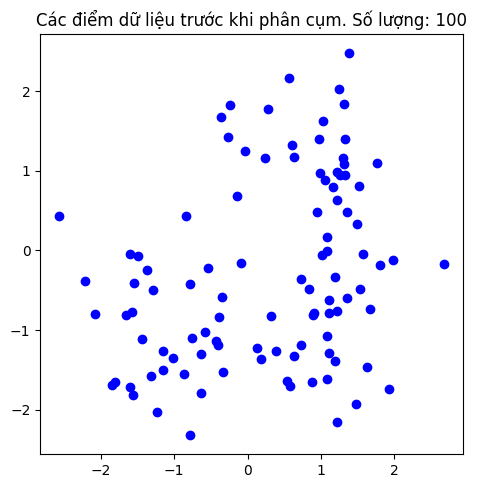

In [3]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()

## Tự xây dựng giải thuật K-means:

Viết code cho giải thuật K-means tại mục này

### Ý tưởng giải thuật

K-means lặp lại hai bước đến khi hội tụ:
1. **Gán nhãn:** mỗi điểm thuộc về **tâm cụm gần nhất** (khoảng cách Euclid).
2. **Cập nhật tâm:** tâm mới = **trung bình** các điểm trong cụm.

Tâm được khởi tạo bằng **k-means++** (chọn các tâm ban đầu phân tán nhau) để giải thuật hội tụ ổn định và cho kết quả gần với `sklearn`. Lặp đến khi tâm gần như không dịch chuyển (< `tol`) hoặc đạt `max_iter`.

In [4]:
class MyKMeans:
    
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def _init_centroids(self, X, rng):
        n = X.shape[0]
        centers = [X[rng.randint(n)]]
        for _ in range(1, self.n_clusters):
            d2 = np.min(euclidean_distances(X, np.array(centers)) ** 2, axis=1)
            probs = d2 / d2.sum()
            centers.append(X[rng.choice(n, p=probs)])
        return np.array(centers)

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.RandomState(self.random_state)
        centers = self._init_centroids(X, rng)
        for it in range(self.max_iter):
            labels = np.argmin(euclidean_distances(X, centers), axis=1)
            new_centers = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j) else X[rng.randint(len(X))]
                for j in range(self.n_clusters)
            ])
            shift = np.linalg.norm(new_centers - centers)
            centers = new_centers
            if shift <= self.tol:
                break
        self.cluster_centers_ = centers
        self.labels_ = labels
        self.inertia_ = float(((X - centers[labels]) ** 2).sum())
        self.n_iter_ = it + 1
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.argmin(euclidean_distances(X, self.cluster_centers_), axis=1)

    def fit_predict(self, X):
        return self.fit(X).labels_

## Kiểm tra giải thuật K-means tự viết cho dữ liệu sinh ngẫu nhiên

- Áp dụng giải thuật K-means tự viết cho tập dữ liệu đã sinh ngẫu nhiên ở trên
- Quan sát kết quả và so sánh với giải thuật của sklearn

Inertia (tổng bình phương khoảng cách trong cụm):
  - K-means tự viết : 70.3266  (số vòng lặp: 6)
  - K-means sklearn : 70.3266


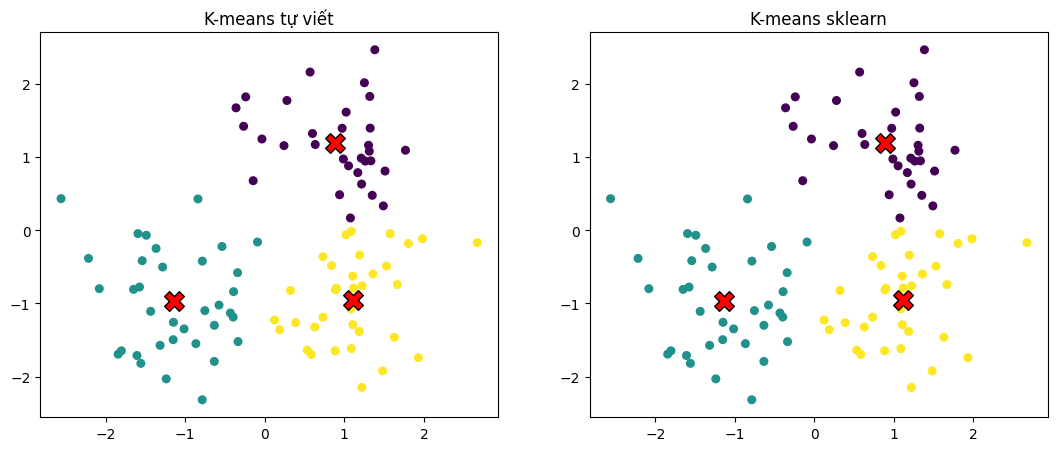

In [5]:
k = 3

my_km = MyKMeans(n_clusters=k, random_state=random_state).fit(X)
sk_km = KMeans(n_clusters=k, n_init=10, random_state=random_state).fit(X)

print("Inertia (tổng bình phương khoảng cách trong cụm):")
print("  - K-means tự viết : {:.4f}  (số vòng lặp: {})".format(my_km.inertia_, my_km.n_iter_))
print("  - K-means sklearn : {:.4f}".format(sk_km.inertia_))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, (title, km) in zip(ax, [("K-means tự viết", my_km), ("K-means sklearn", sk_km)]):
    a.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="viridis", s=30)
    a.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
              c="red", marker="X", s=200, edgecolor="black")
    a.set_title(title)
plt.show()

**Nhận xét:** hai cách cho **cùng cách phân cụm** (số thứ tự/màu của cụm có thể khác nhau là bình thường, vì nhãn cụm chỉ là tên gọi). Giá trị **inertia xấp xỉ nhau** ⇒ giải thuật tự viết hoạt động đúng và tương đương `sklearn`.

## Ứng dụng K-means tự viết vào nén ảnh 

### Thư viện sử dụng - hỗ trợ hình ảnh 

In [6]:
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from IPython.display import Image, display

### Đọc dữ liệu hình ảnh
- Mỗi điểm ảnh là 1 mẫu quan sát 
- Phân cụm tập dữ liệu (tập các điểm ảnh) về k nhãn

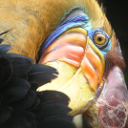

Số chiều của dữ liệu hình ảnh:  (16384, 3)
Tổng số điểm ảnh là:  16384
Mỗi điểm ảnh có số chiều =  3


In [7]:
path_img = 'bird_small.png'
display(Image(path_img, width=250, unconfined=True))
img = io.imread(path_img)
data_img = (img / 255.0).reshape(-1,img.shape[2]) # chuyển ma trận 128x128x3 về mảng 2 chiều 
img_shape = img.shape                    

print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

### Nén ảnh bằng giải thuật K-means tự viết

- Tạo file nén ảnh bằng giải thuật K-means tự viết
- Hiển thị kết quả của giải thuật tự viết và giải thuật của sklearn để so sánh


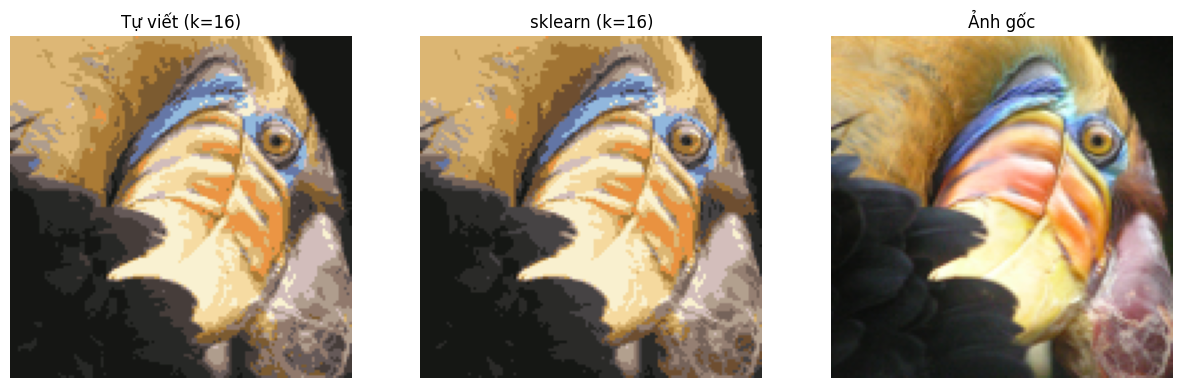

In [8]:
k_colors = 16   # số màu sau khi nén (có thể thử các giá trị khác: 8, 32, ...)

km_my = MyKMeans(n_clusters=k_colors, random_state=0).fit(data_img)
img_my = km_my.cluster_centers_[km_my.labels_].reshape(img_shape)

km_sk = KMeans(n_clusters=k_colors, n_init=10, random_state=0).fit(data_img)
img_sk = km_sk.cluster_centers_[km_sk.labels_].reshape(img_shape)

plt.imsave("img_128.png", np.clip(img_my, 0, 1))   # kết quả tự viết
plt.imsave("img128.png", np.clip(img_sk, 0, 1))     # kết quả thư viện

# Hiển thị so sánh: tự viết | sklearn | ảnh gốc
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Tự viết (k={})".format(k_colors), "sklearn (k={})".format(k_colors), "Ảnh gốc"]
for a, im, t in zip(ax, [img_my, img_sk, img / 255.0], titles):
    a.imshow(np.clip(im, 0, 1)); a.set_title(t); a.axis("off")
plt.show()

**Nhận xét:** ảnh nén bằng giải thuật tự viết và bằng `sklearn` nhìn **tương đương** — đều rút gọn còn `k_colors` màu nhưng vẫn giữ được nội dung ảnh. Nén có ý nghĩa vì chỉ cần lưu **`k_colors` màu** + **chỉ số cụm** cho mỗi điểm ảnh, thay vì giá trị RGB đầy đủ.

Ví dụ

Ảnh nén bằng K-means tự viết


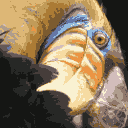

Ảnh nén bằng K-means của thư viện 


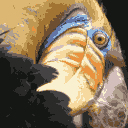

Ảnh gốc


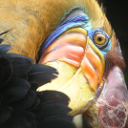

In [9]:
print('Ảnh nén bằng K-means tự viết')
display(Image('img_128.png', width=250, unconfined=True))#kết quả tự cài đặt
print('Ảnh nén bằng K-means của thư viện ')
display(Image('img128.png', width=250, unconfined=True)) #kết quả của thư viện
print('Ảnh gốc')
display(Image(path_img, width=250, unconfined=True))